# 决策树与集成树模型的性能比较

本实验在乳腺癌分类数据与糖尿病回归数据上比较决策树、随机森林、GBDT 与 XGBoost。两个任务都按照 6:2:2 划分训练集、验证集与测试集：每个候选模型只在训练集上拟合，分类任务以验证集 AUROC 选择参数，回归任务以验证集 RMSE 选择参数。

In [1]:
import matplotlib.pyplot as plt
from figure_settings import configure_matplotlib

configure_matplotlib()

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    ParameterGrid,
    train_test_split,
)
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier, XGBRegressor

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42
MODEL_COLORS = {
    "Decision tree": "#4C78A8",
    "Random forest": "#59A14F",
    "GBDT": "#F28E2B",
    "XGBoost": "#E45756",
}


def parameter_text(parameters):
    return ", ".join(
        f"{name}={value!r}" for name, value in sorted(parameters.items())
    )

## 1. 调参规则

四个模型分别搜索 48、36、36 与 32 组参数。每个模型使用完全相同的数据划分和评价指标。

In [2]:
classification_parameter_grids = {
    "Decision tree": {
        "max_depth": [1, 2, 3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 2, 5, 10, 20, 30],
    },
    "Random forest": {
        "n_estimators": [200, 500],
        "max_depth": [6, 12, None],
        "min_samples_leaf": [1, 3, 6],
        "max_features": ["sqrt", 0.5],
    },
    "GBDT": {
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.10],
        "max_depth": [1, 2, 3],
        "min_samples_leaf": [5, 10, 20],
    },
    "XGBoost": {
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.10],
        "max_depth": [2, 3],
        "min_child_weight": [1, 5],
        "reg_lambda": [1.0, 5.0],
    },
}

regression_parameter_grids = {
    "Decision tree": {
        "max_depth": [1, 2, 3, 4, 5, 6, 8, None],
        "min_samples_leaf": [1, 2, 5, 10, 20, 30],
    },
    "Random forest": {
        "n_estimators": [200, 500],
        "max_depth": [6, 12, None],
        "min_samples_leaf": [1, 3, 6],
        "max_features": [0.5, 1.0],
    },
    "GBDT": {
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.10],
        "max_depth": [1, 2, 3],
        "min_samples_leaf": [5, 10, 20],
    },
    "XGBoost": {
        "n_estimators": [100, 300],
        "learning_rate": [0.03, 0.10],
        "max_depth": [2, 3],
        "min_child_weight": [1, 5],
        "reg_lambda": [1.0, 5.0],
    },
}

## 2. 乳腺癌分类

### 2.1 数据划分

仍将恶性样本记为正类 1，良性样本记为 0。先按类别比例划出 60% 的训练集，再将剩余样本等分为验证集与测试集；两次划分都使用同一个随机种子并保持类别比例。

In [3]:
cancer = load_breast_cancer()
X_classification = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_classification = pd.Series(
    (cancer.target == 0).astype(int),
    name="malignant",
)

(
    X_classification_train,
    X_classification_remaining,
    y_classification_train,
    y_classification_remaining,
) = train_test_split(
    X_classification,
    y_classification,
    test_size=0.40,
    stratify=y_classification,
    random_state=RANDOM_STATE,
)
(
    X_classification_validation,
    X_classification_test,
    y_classification_validation,
    y_classification_test,
) = train_test_split(
    X_classification_remaining,
    y_classification_remaining,
    test_size=0.50,
    stratify=y_classification_remaining,
    random_state=RANDOM_STATE,
)

In [4]:
def classification_metrics(model, features, labels):
    prediction = model.predict(features)
    probability = model.predict_proba(features)[:, 1]
    return {
        "Accuracy": accuracy_score(labels, prediction),
        "Precision": precision_score(labels, prediction, zero_division=0),
        "Recall": recall_score(labels, prediction),
        "F1": f1_score(labels, prediction),
        "AUROC": roc_auc_score(labels, probability),
    }

### 2.2 四种模型调参

每个候选模型只在训练集上拟合，并计算训练 AUROC 与验证 AUROC。选择验证 AUROC 最大的候选。

In [5]:
def tune_classifier(estimator, parameter_grid):
    rows = []
    fitted_candidates = {}
    for candidate_id, parameters in enumerate(ParameterGrid(parameter_grid), start=1):
        candidate = clone(estimator).set_params(**parameters)
        candidate.fit(X_classification_train, y_classification_train)
        training_metrics = classification_metrics(
            candidate,
            X_classification_train,
            y_classification_train,
        )
        validation_metrics = classification_metrics(
            candidate,
            X_classification_validation,
            y_classification_validation,
        )
        rows.append(
            {
                "candidate": candidate_id,
                "parameters": parameters,
                "parameters text": parameter_text(parameters),
                "training AUROC": training_metrics["AUROC"],
                "validation Accuracy": validation_metrics["Accuracy"],
                "validation Precision": validation_metrics["Precision"],
                "validation Recall": validation_metrics["Recall"],
                "validation F1": validation_metrics["F1"],
                "validation AUROC": validation_metrics["AUROC"],
            }
        )
        fitted_candidates[candidate_id] = candidate

    results = pd.DataFrame(rows)
    selected = results.loc[results["validation AUROC"].idxmax()]
    return fitted_candidates[int(selected["candidate"])], selected, results


classification_estimators = {
    "Decision tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "GBDT": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        subsample=0.8,
    ),
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
    ),
}

classification_tuned_models = {}
classification_selected_rows = {}
classification_search_results = {}

for model_name, estimator in classification_estimators.items():
    fitted_model, selected, results = tune_classifier(
        estimator,
        classification_parameter_grids[model_name],
    )
    classification_tuned_models[model_name] = fitted_model
    classification_selected_rows[model_name] = selected
    classification_search_results[model_name] = results

先给出各模型验证 AUROC 排名最高的五组候选，再汇总最终选定的参数。

In [6]:
for model_name, results in classification_search_results.items():
    print(f"{model_name}: top five candidates")
    top_candidates = (
        results.sort_values(
            "validation AUROC",
            ascending=False,
        )
        .head(5)[
            [
                "parameters text",
                "training AUROC",
                "validation AUROC",
                "validation Accuracy",
                "validation Precision",
                "validation Recall",
                "validation F1",
            ]
        ]
    )
    display(top_candidates.round(3))

classification_tuning_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "training AUROC": selected["training AUROC"],
            "validation AUROC": selected["validation AUROC"],
            "validation Accuracy": selected["validation Accuracy"],
            "validation Precision": selected["validation Precision"],
            "validation Recall": selected["validation Recall"],
            "validation F1": selected["validation F1"],
        }
        for model_name, selected in classification_selected_rows.items()
    ]
).set_index("model")
display(classification_tuning_summary.round(3))
for model_name, selected in classification_selected_rows.items():
    print(f"{model_name}: {parameter_text(selected['parameters'])}")

Decision tree: top five candidates


,parameters text,training AUROC,validation AUROC,validation Accuracy,validation Precision,validation Recall,validation F1
34,"max_depth=6, min_samples_leaf=20",0.988,0.985,0.939,0.929,0.907,0.918
40,"max_depth=8, min_samples_leaf=20",0.988,0.985,0.939,0.929,0.907,0.918
46,"max_depth=None, min_samples_leaf=20",0.988,0.985,0.939,0.929,0.907,0.918
28,"max_depth=5, min_samples_leaf=20",0.988,0.985,0.939,0.929,0.907,0.918
17,"max_depth=3, min_samples_leaf=30",0.977,0.978,0.947,0.911,0.953,0.932


Random forest: top five candidates


,parameters text,training AUROC,validation AUROC,validation Accuracy,validation Precision,validation Recall,validation F1
0,"max_depth=6, max_features='sqrt', min_samples_...",1.000,0.995,0.956,0.975,0.907,0.940
12,"max_depth=12, max_features='sqrt', min_samples...",1.000,0.995,0.956,0.975,0.907,0.940
24,"max_depth=None, max_features='sqrt', min_sampl...",1.000,0.995,0.956,0.975,0.907,0.940
27,"max_depth=None, max_features='sqrt', min_sampl...",0.999,0.994,0.956,0.975,0.907,0.940
9,"max_depth=6, max_features=0.5, min_samples_lea...",0.999,0.994,0.965,0.976,0.930,0.952


GBDT: top five candidates


,parameters text,training AUROC,validation AUROC,validation Accuracy,validation Precision,validation Recall,validation F1
19,"learning_rate=0.1, max_depth=1, min_samples_le...",1.0,1.0,0.982,1.0,0.953,0.976
23,"learning_rate=0.1, max_depth=1, min_samples_le...",1.0,1.0,0.982,1.0,0.953,0.976
21,"learning_rate=0.1, max_depth=1, min_samples_le...",1.0,1.0,0.982,1.0,0.953,0.976
29,"learning_rate=0.1, max_depth=2, min_samples_le...",1.0,1.0,0.974,1.0,0.930,0.964
35,"learning_rate=0.1, max_depth=3, min_samples_le...",1.0,1.0,0.974,1.0,0.930,0.964


XGBoost: top five candidates


,parameters text,training AUROC,validation AUROC,validation Accuracy,validation Precision,validation Recall,validation F1
26,"learning_rate=0.1, max_depth=3, min_child_weig...",1.000,1.000,0.982,1.0,0.953,0.976
18,"learning_rate=0.1, max_depth=2, min_child_weig...",1.000,1.000,0.982,1.0,0.953,0.976
16,"learning_rate=0.1, max_depth=2, min_child_weig...",1.000,0.999,0.982,1.0,0.953,0.976
14,"learning_rate=0.03, max_depth=3, min_child_wei...",0.997,0.999,0.982,1.0,0.953,0.976
30,"learning_rate=0.1, max_depth=3, min_child_weig...",0.998,0.999,0.974,1.0,0.930,0.964


,training AUROC,validation AUROC,validation Accuracy,validation Precision,validation Recall,validation F1
model,,,,,,
Decision tree,0.988,0.985,0.939,0.929,0.907,0.918
Random forest,1.000,0.995,0.956,0.975,0.907,0.940
GBDT,1.000,1.000,0.982,1.000,0.953,0.976
XGBoost,1.000,1.000,0.982,1.000,0.953,0.976


Decision tree: max_depth=5, min_samples_leaf=20
Random forest: max_depth=6, max_features='sqrt', min_samples_leaf=1, n_estimators=200
GBDT: learning_rate=0.1, max_depth=1, min_samples_leaf=5, n_estimators=300
XGBoost: learning_rate=0.1, max_depth=2, min_child_weight=1, n_estimators=300, reg_lambda=1.0


### 2.3 独立测试集性能

全部参数确定后，统一在独立测试集上计算 Accuracy、Precision、Recall、F1 与 AUROC。分类阈值为 0.5，AUROC 使用预测为恶性的概率。

In [7]:
classification_models = classification_tuned_models

classification_rows = []
for model_name, model in classification_models.items():
    for data_name, features, labels in [
        (
            "training",
            X_classification_train,
            y_classification_train,
        ),
        (
            "validation",
            X_classification_validation,
            y_classification_validation,
        ),
        ("test", X_classification_test, y_classification_test),
    ]:
        classification_rows.append(
            {
                "model": model_name,
                "data": data_name,
                **classification_metrics(model, features, labels),
            }
        )

classification_comparison = pd.DataFrame(classification_rows).set_index(
    ["model", "data"]
)
classification_test_comparison = classification_comparison.xs(
    "test",
    level="data",
).copy()
classification_test_comparison["AUROC difference from tree"] = (
    classification_test_comparison["AUROC"]
    - classification_test_comparison.loc["Decision tree", "AUROC"]
)
display(classification_comparison.round(3))
display(classification_test_comparison.round(3))

Accuracy  Precision  Recall     F1  AUROC
model         data                                                 
Decision tree training       0.947      0.936   0.921  0.929  0.988
              validation     0.939      0.929   0.907  0.918  0.985
              test           0.939      0.973   0.857  0.911  0.950
Random forest training       0.994      1.000   0.984  0.992  1.000
              validation     0.956      0.975   0.907  0.940  0.995
              test           0.974      1.000   0.929  0.963  0.995
GBDT          training       1.000      1.000   1.000  1.000  1.000
              validation     0.982      1.000   0.953  0.976  1.000
              test           0.982      1.000   0.952  0.976  0.993
XGBoost       training       1.000      1.000   1.000  1.000  1.000
              validation     0.982      1.000   0.953  0.976  1.000
              test           0.974      1.000   0.929  0.963  0.990

,Accuracy,Precision,Recall,F1,AUROC,AUROC difference from tree
model,,,,,,
Decision tree,0.939,0.973,0.857,0.911,0.950,0.000
Random forest,0.974,1.000,0.929,0.963,0.995,0.045
GBDT,0.982,1.000,0.952,0.976,0.993,0.043
XGBoost,0.974,1.000,0.929,0.963,0.990,0.041


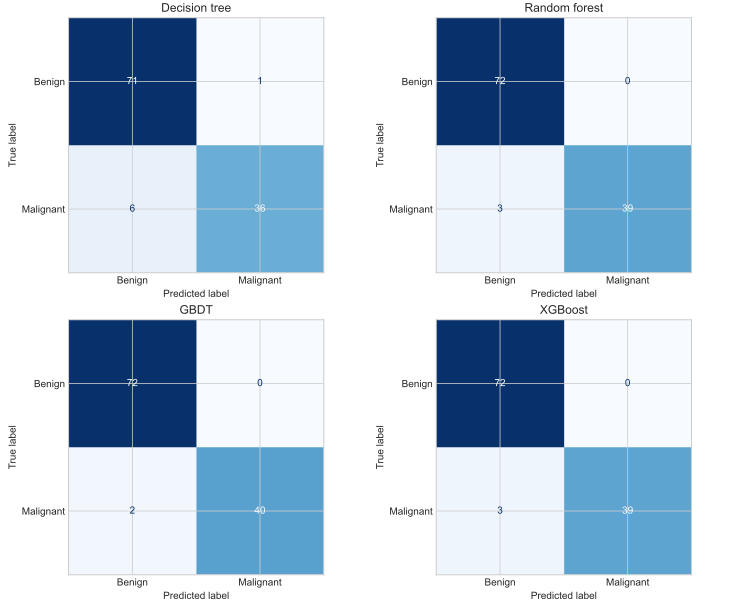

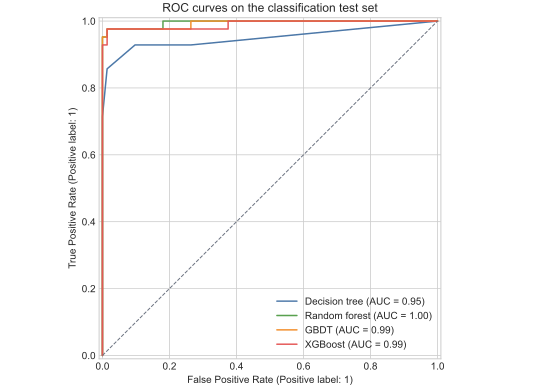

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.4), constrained_layout=True)
for ax, (model_name, model) in zip(axes.flat, classification_models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_classification_test,
        model.predict(X_classification_test),
        display_labels=["Benign", "Malignant"],
        colorbar=False,
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(model_name)
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 5.4), constrained_layout=True)
for model_name, model in classification_models.items():
    RocCurveDisplay.from_predictions(
        y_classification_test,
        model.predict_proba(X_classification_test)[:, 1],
        name=model_name,
        curve_kwargs={"color": MODEL_COLORS[model_name]},
        ax=ax,
    )
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#6B7280",
    linewidth=1,
)
ax.set_title("ROC curves on the classification test set")
plt.show()

## 3. 糖尿病回归

### 3.1 数据划分

使用两次随机划分得到 60% 的训练集、20% 的验证集和 20% 的测试集。所有候选模型只在训练集上拟合，验证集用于选参。

In [9]:
diabetes = load_diabetes(as_frame=True)
X_regression = diabetes.data
y_regression = diabetes.target.rename("disease progression")

X_train, X_remaining, y_train, y_remaining = train_test_split(
    X_regression,
    y_regression,
    test_size=0.40,
    random_state=RANDOM_STATE,
)
X_validation, X_regression_test, y_validation, y_regression_test = (
    train_test_split(
        X_remaining,
        y_remaining,
        test_size=0.50,
        random_state=RANDOM_STATE,
    )
)

regression_split = pd.DataFrame(
    {
        "samples": [
            len(X_train),
            len(X_validation),
            len(X_regression_test),
        ],
        "proportion": [
            len(X_train) / len(X_regression),
            len(X_validation) / len(X_regression),
            len(X_regression_test) / len(X_regression),
        ],
        "purpose": [
            "fit candidate models",
            "select hyperparameters",
            "final evaluation",
        ],
    },
    index=["training", "validation", "test"],
)
display(regression_split.round({"proportion": 3}))

,samples,proportion,purpose
training,265,0.600,fit candidate models
validation,88,0.199,select hyperparameters
test,89,0.201,final evaluation


In [10]:
def regression_metrics(response, prediction):
    return {
        "MAE": mean_absolute_error(response, prediction),
        "RMSE": np.sqrt(mean_squared_error(response, prediction)),
        "R2": r2_score(response, prediction),
    }

### 3.2 四种模型调参

每组参数都只在训练集上拟合，然后在同一个验证集上计算 MAE、RMSE 与 $R^2$。选择验证 RMSE 最小的候选。

In [11]:
def tune_regressor(estimator, parameter_grid):
    rows = []
    fitted_candidates = {}
    for candidate_id, parameters in enumerate(ParameterGrid(parameter_grid), start=1):
        candidate = clone(estimator).set_params(**parameters)
        candidate.fit(X_train, y_train)
        prediction = candidate.predict(X_validation)
        rows.append(
            {
                "candidate": candidate_id,
                "parameters": parameters,
                "parameters text": parameter_text(parameters),
                **regression_metrics(y_validation, prediction),
            }
        )
        fitted_candidates[candidate_id] = candidate

    results = pd.DataFrame(rows)
    selected = results.loc[results["RMSE"].idxmin()]
    return fitted_candidates[int(selected["candidate"])], selected, results


regression_estimators = {
    "Decision tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "GBDT": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        subsample=0.8,
        loss="squared_error",
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=0,
    ),
}

regression_tuned_models = {}
regression_selected_rows = {}
regression_search_results = {}

for model_name, estimator in regression_estimators.items():
    fitted_model, selected, results = tune_regressor(
        estimator,
        regression_parameter_grids[model_name],
    )
    regression_tuned_models[model_name] = fitted_model
    regression_selected_rows[model_name] = selected
    regression_search_results[model_name] = results

In [12]:
for model_name, results in regression_search_results.items():
    print(f"{model_name}: top five candidates")
    top_candidates = (
        results.sort_values(
            "RMSE",
            ascending=True,
        )
        .head(5)[["parameters text", "MAE", "RMSE", "R2"]]
    )
    display(top_candidates.round(3))

regression_tuning_summary = pd.DataFrame(
    [
        {
            "model": model_name,
            "validation MAE": selected["MAE"],
            "validation RMSE": selected["RMSE"],
            "validation R2": selected["R2"],
            "selected parameters": parameter_text(selected["parameters"]),
        }
        for model_name, selected in regression_selected_rows.items()
    ]
).set_index("model")
display(regression_tuning_summary.round(3))
for model_name, selected in regression_selected_rows.items():
    print(f"{model_name}: {parameter_text(selected['parameters'])}")

Decision tree: top five candidates


,parameters text,MAE,RMSE,R2
17,"max_depth=3, min_samples_leaf=30",41.586,53.218,0.509
23,"max_depth=4, min_samples_leaf=30",41.990,53.934,0.495
41,"max_depth=8, min_samples_leaf=30",41.990,53.934,0.495
35,"max_depth=6, min_samples_leaf=30",41.990,53.934,0.495
29,"max_depth=5, min_samples_leaf=30",41.990,53.934,0.495


Random forest: top five candidates


,parameters text,MAE,RMSE,R2
2,"max_depth=6, max_features=0.5, min_samples_lea...",41.677,51.664,0.537
14,"max_depth=12, max_features=0.5, min_samples_le...",41.802,51.882,0.533
3,"max_depth=6, max_features=0.5, min_samples_lea...",41.752,51.922,0.532
26,"max_depth=None, max_features=0.5, min_samples_...",41.828,51.940,0.532
15,"max_depth=12, max_features=0.5, min_samples_le...",41.986,52.033,0.530


GBDT: top five candidates


,parameters text,MAE,RMSE,R2
22,"learning_rate=0.1, max_depth=1, min_samples_le...",39.344,50.285,0.561
3,"learning_rate=0.03, max_depth=1, min_samples_l...",39.512,50.519,0.557
1,"learning_rate=0.03, max_depth=1, min_samples_l...",39.548,50.526,0.557
18,"learning_rate=0.1, max_depth=1, min_samples_le...",39.948,50.548,0.557
5,"learning_rate=0.03, max_depth=1, min_samples_l...",39.549,50.555,0.557


XGBoost: top five candidates


,parameters text,MAE,RMSE,R2
20,"learning_rate=0.1, max_depth=2, min_child_weig...",40.526,50.519,0.557
21,"learning_rate=0.1, max_depth=2, min_child_weig...",40.325,50.526,0.557
17,"learning_rate=0.1, max_depth=2, min_child_weig...",40.092,50.616,0.556
7,"learning_rate=0.03, max_depth=2, min_child_wei...",39.965,50.621,0.556
3,"learning_rate=0.03, max_depth=2, min_child_wei...",40.177,50.786,0.553


,validation MAE,validation RMSE,validation R2,selected parameters
model,,,,
Decision tree,41.586,53.218,0.509,"max_depth=3, min_samples_leaf=30"
Random forest,41.677,51.664,0.537,"max_depth=6, max_features=0.5, min_samples_lea..."
GBDT,39.344,50.285,0.561,"learning_rate=0.1, max_depth=1, min_samples_le..."
XGBoost,40.526,50.519,0.557,"learning_rate=0.1, max_depth=2, min_child_weig..."


Decision tree: max_depth=3, min_samples_leaf=30
Random forest: max_depth=6, max_features=0.5, min_samples_leaf=3, n_estimators=200
GBDT: learning_rate=0.1, max_depth=1, min_samples_leaf=20, n_estimators=100
XGBoost: learning_rate=0.1, max_depth=2, min_child_weight=5, n_estimators=100, reg_lambda=1.0


### 3.3 独立测试集性能

全部参数确定后，统一在独立测试集上报告 MAE、RMSE 与 $R^2$。RMSE 相对决策树的改善比例定义为：

$$
\frac{\operatorname{RMSE}_{\mathrm{tree}}-\operatorname{RMSE}_{\mathrm{model}}}
{\operatorname{RMSE}_{\mathrm{tree}}}.
$$

正值表示测试 RMSE 低于决策树。

In [13]:
regression_models = regression_tuned_models

regression_rows = []
regression_predictions = {}
for model_name, model in regression_models.items():
    prediction = model.predict(X_regression_test)
    regression_predictions[model_name] = prediction
    regression_rows.append(
        {
            "model": model_name,
            **regression_metrics(y_regression_test, prediction),
        }
    )

regression_test_comparison = pd.DataFrame(regression_rows).set_index("model")
tree_rmse = regression_test_comparison.loc["Decision tree", "RMSE"]
regression_test_comparison["RMSE improvement over tree"] = (
    tree_rmse - regression_test_comparison["RMSE"]
) / tree_rmse
display(regression_test_comparison.round(3))

,MAE,RMSE,R2,RMSE improvement over tree
model,,,,
Decision tree,49.292,62.859,0.317,0.000
Random forest,45.040,55.459,0.468,0.118
GBDT,45.088,54.993,0.477,0.125
XGBoost,45.080,55.483,0.468,0.117


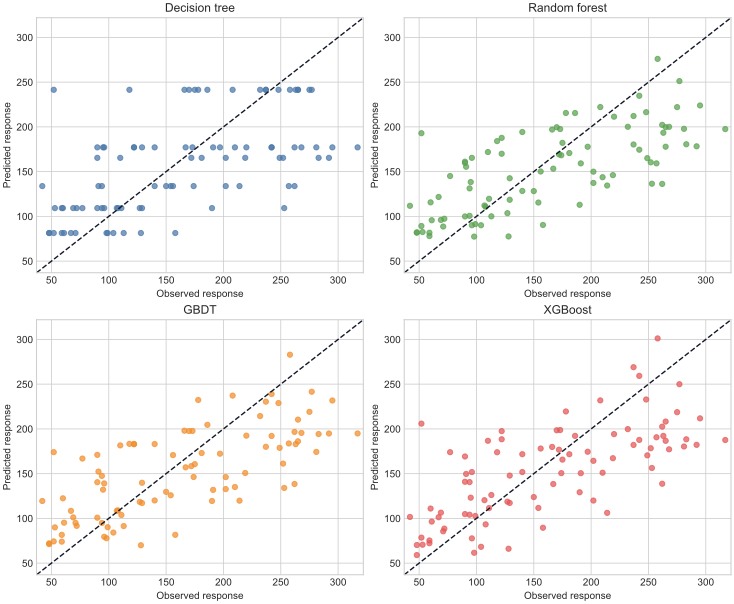

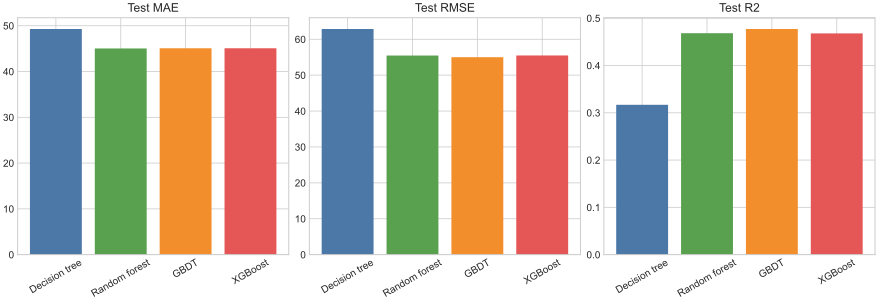

In [14]:
plot_min = min(
    y_regression_test.min(),
    *(prediction.min() for prediction in regression_predictions.values()),
) - 5
plot_max = max(
    y_regression_test.max(),
    *(prediction.max() for prediction in regression_predictions.values()),
) + 5

fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.4), constrained_layout=True)
for ax, (model_name, prediction) in zip(
    axes.flat,
    regression_predictions.items(),
):
    ax.scatter(
        y_regression_test,
        prediction,
        s=28,
        alpha=0.72,
        color=MODEL_COLORS[model_name],
    )
    ax.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        linestyle="--",
        linewidth=1.4,
        color="#111827",
    )
    ax.set(
        title=model_name,
        xlabel="Observed response",
        ylabel="Predicted response",
        xlim=(plot_min, plot_max),
        ylim=(plot_min, plot_max),
    )
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12.2, 4.2), constrained_layout=True)
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    values = regression_test_comparison[metric]
    ax.bar(
        values.index,
        values,
        color=[MODEL_COLORS[name] for name in values.index],
    )
    ax.set_title(f"Test {metric}")
    ax.tick_params(axis="x", rotation=30)
plt.show()